# ImageNet-100 - ConvNeXt-Tiny

Train the local **ConvNeXt-Tiny** implementation inline in this notebook on ImageNet-100.

ConvNeXt uses a patch-style stem, depthwise 7x7 convolutions, channels-last LayerNorm inside each block, GELU MLP blocks, layer scale, and stochastic depth.

| Hyper-parameter | Value |
|-----------------|-------|
| Model | `ConvNextT` |
| Depths | [3, 3, 9, 3] |
| Dims | [96, 192, 384, 768] |
| Input size | 224x224 |
| Classes | 100 |
| Optimizer | AdamW |
| Scheduler | OneCycleLR |


## Imports


In [1]:
import sys
sys.path.append('../..')

import torch
import torch.nn as nn
from torch import optim
import torchvision.transforms as transforms

from utils.dataset import get_imagenet100_dataloaders
from utils.training import fit, test_accuracy
from utils.callbacks import ModelCheckpoint
from utils.plotting import plot_training_curves, show_sample_batch


## ConvNeXt-Tiny Model Definition

Custom implementation with depthwise 7×7 convolutions, GELU, LayerNorm, layer scale, and stochastic depth.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class StochasticDepth(nn.Module):
    """Drop Path (Stochastic Depth) regularization per block."""
    def __init__(self, drop_prob: float = 0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if not self.training or self.drop_prob == 0.0:
            return x
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor = torch.floor(random_tensor + keep_prob)
        return x * random_tensor / keep_prob

class LayerNorm2d(nn.Module):
    """
    LayerNorm that supports (N, C, H, W) inputs.
    We permute to (N, H, W, C), apply standard nn.LayerNorm, and permute back.
    """
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.norm = nn.LayerNorm(dim, eps=eps)

    def forward(self, x):
        return self.norm(x.permute(0, 2, 3, 1)).permute(0, 3, 1, 2)

class ConvNeXtBlock(nn.Module):

    def __init__(self, dim, layer_scale_init_value=1e-6, drop_path=0.,):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)
        self.norm = nn.LayerNorm(dim, eps=1e-6)
        self.pwconv1 = nn.Linear(dim, 4 * dim)
        self.act = nn.GELU()
        self.pwconv2 = nn.Linear(4 * dim, dim)
        self.gamma = nn.Parameter(
            layer_scale_init_value * torch.ones((dim)), requires_grad=True
        ) if layer_scale_init_value > 0 else None
        self.drop_path = StochasticDepth(drop_path) if drop_path > 0. else nn.Identity()

    def forward(self, x):
        input = x
        x = self.dwconv(x)
        x = x.permute(0, 2, 3, 1)
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.pwconv2(x)
        if self.gamma is not None:
            x = self.gamma * x
        x = x.permute(0, 3, 1, 2)
        
        x = input + self.drop_path(x)
        return x


class ConvNextT(nn.Module):
    """
    ConvNeXt-Tiny for ImageNet (224x224).
    Standard architecture: 
    - Stem: 4x4 conv, stride 4
    - Stages: [3, 3, 9, 3] blocks
    - Dims: [96, 192, 384, 768]
    """
    def __init__(self,drop_path_rate = 0.1, num_classes: int=100) -> None:
        super().__init__()
        
        depths = [3, 3, 9, 3]
        dims = [96, 192, 384, 768]

        
        self.downsample_layers = nn.ModuleList()

        stem = nn.Sequential(
            nn.Conv2d(3, dims[0], kernel_size=4, stride=4),
            LayerNorm2d(dims[0], eps=1e-6)
        )
        self.downsample_layers.append(stem)

        for i in range(3):
            downsample_layer = nn.Sequential(
                LayerNorm2d(dims[i], eps=1e-6),
                nn.Conv2d(dims[i], dims[i+1], kernel_size=2, stride=2),
            )
            self.downsample_layers.append(downsample_layer)
            
        self.stages = nn.ModuleList()
        dp_rates = [x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))]
        cur = 0
        for i in range(4):
            stage = nn.Sequential(
                *[ConvNeXtBlock(dim=dims[i], drop_path=dp_rates[cur + j],) for j in range(depths[i])]
            )
            self.stages.append(stage)
            cur += depths[i]
            
        self.norm = nn.LayerNorm(dims[-1], eps=1e-6)
        self.fc = nn.Linear(dims[-1], num_classes)
        
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.trunc_normal_(m.weight, std=.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        for i in range(4):
            x = self.downsample_layers[i](x)
            x = self.stages[i](x)

        x = x.mean([-2, -1])
        x = self.norm(x)
        x = self.fc(x)
        return x


## Device Setup


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
print(f'Using device: {device}')


Using device: cuda


## Data Pipeline


In [3]:
batch_size = 192
img_size = 224

trainloader, valloader, testloader = get_imagenet100_dataloaders(
    batch_size=batch_size,
    num_workers=4,
    img_size=img_size,
    interpolation=transforms.InterpolationMode.BICUBIC,
)

# Prefer class names from the Hugging Face dataset metadata when available.
label_feature = trainloader.dataset.hf_dataset.features.get('label')
from utils.dataset import IMAGENET100_CLASSES

print(f'Train batches: {len(trainloader)} | Val batches: {len(valloader)} | Test batches: {len(testloader)}')
print(f'Classes: {len(IMAGENET100_CLASSES)}')


C:\Users\asmit\PycharmProjects\CIFAR_10\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Dataset] Loading 'ilee0022/ImageNet100' (local cache: C:\Users\asmit\PycharmProjects\CIFAR_10\data\huggingface)...
Train batches: 610 | Val batches: 27 | Test batches: 68
Classes: 100


## Visualize Sample Batch


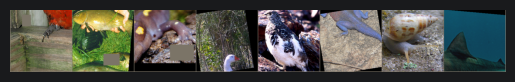

lorikeet scorpion whiptail, whiptail lizard green lizard, Lacerta viridis albatross, mollymawk snail nematode, nematode worm, roundworm goldfinch, Carduelis carduelis


In [4]:
show_sample_batch(trainloader, IMAGENET100_CLASSES)


## Model Definition

The model is imported inline in this notebook so this notebook trains the same implementation used by the rest of the project.

`ConvNextT` expects 224x224 RGB inputs and exposes `num_classes` for ImageNet-100 classification.


## Initialize Model & Print Summary


In [5]:
# from torchvision.models import convnext_tiny

model = ConvNextT(num_classes=100, drop_path_rate=0.1).to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')


ConvNextT(
  (downsample_layers): ModuleList(
    (0): Sequential(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d(
        (norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
      )
    )
    (1): Sequential(
      (0): LayerNorm2d(
        (norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
      )
      (1): Conv2d(96, 192, kernel_size=(2, 2), stride=(2, 2))
    )
    (2): Sequential(
      (0): LayerNorm2d(
        (norm): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      )
      (1): Conv2d(192, 384, kernel_size=(2, 2), stride=(2, 2))
    )
    (3): Sequential(
      (0): LayerNorm2d(
        (norm): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      )
      (1): Conv2d(384, 768, kernel_size=(2, 2), stride=(2, 2))
    )
  )
  (stages): ModuleList(
    (0): Sequential(
      (0): ConvNeXtBlock(
        (dwconv): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
        (norm): LayerN

## Training Configuration


In [6]:
criterion = nn.CrossEntropyLoss()
epochs = 90
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=4e-3,
    weight_decay=0.05
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

# scheduler = optim.lr_scheduler.OneCycleLR(
#     optimizer,
#     max_lr=6e-3,
#     steps_per_epoch=len(trainloader),
#     epochs=epochs,
#     pct_start=0.1,
#     anneal_strategy='cos',
#     div_factor=10,
#     final_div_factor=1e4,
# )

scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))

NAME = 'convnext_tiny_imagenet100_v6'
checkpoint = ModelCheckpoint(
    model=model,
    checkpoint_path=f'../../checkpoint/{NAME}_latest.pth',
    best_model_path=f'../../checkpoint/{NAME}_best.pth',
    mode='max',
    verbose=False,
)


## Training Loop


In [7]:
train_losses, val_losses, val_accuracies = fit(
    model, trainloader, valloader, criterion,
    optimizer, scheduler, scaler, device, epochs, checkpoint,
    step_scheduler_per_batch=False,
    log=True, resume_from_checkpoint=True
)


[RunLogger] ▶  Run 'convnextt_20260614_095527' started — saving to 'C:\Users\asmit\PycharmProjects\CIFAR_10\logs\runs\convnextt_20260614_095527.json'
[RunLogger] Logging to 'C:\Users\asmit\PycharmProjects\CIFAR_10\logs\runs/'  —  run: 'convnextt_20260614_095527'
[Warning] No checkpoint found at '..\checkpoint\convnext_tiny_imagenet100_v6_latest.pth'. Cannot resume training. Starting from epoch 0.
[RunLogger] Epoch   1 | train_loss=4.3903  val_loss=4.1253  val_metric=5.26 %  lr=4.00e-03  ⏱ 162.7s  ★ NEW BEST
Epoch [ 1/90]  Train Loss: 4.3903  Val Loss: 4.1253  Val Acc: 5.26%  LR: 0.003999  Time: 162.69s
[RunLogger] Epoch   2 | train_loss=4.0743  val_loss=3.7037  val_metric=12.10 %  lr=4.00e-03  ⏱ 140.7s  ★ NEW BEST
Epoch [ 2/90]  Train Loss: 4.0743  Val Loss: 3.7037  Val Acc: 12.10%  LR: 0.003995  Time: 140.68s
[RunLogger] Epoch   3 | train_loss=3.7299  val_loss=3.2730  val_metric=20.44 %  lr=3.99e-03  ⏱ 141.2s  ★ NEW BEST
Epoch [ 3/90]  Train Loss: 3.7299  Val Loss: 3.2730  Val Acc: 20

## Restore Best Weights & Test Evaluation


In [8]:
checkpoint.restore_best_weights()

overall_acc, per_class = test_accuracy(model, testloader, IMAGENET100_CLASSES, device)
print(f'\nOverall Test Accuracy: {overall_acc:.2f}%\n')
for name, acc in per_class.items():
    print(f'  {name:24s}: {acc:.1f}%')



Overall Test Accuracy: 86.18%

  American alligator, Alligator mississipiensis: 91.2%
  American coot, marsh hen, mud hen, water hen, Fulica americana: 83.8%
  Dungeness crab, Cancer magister: 97.5%
  Komodo dragon, Komodo lizard, dragon lizard, giant lizard, Varanus komodoensis: 94.2%
  agama                   : 98.3%
  albatross, mollymawk    : 92.3%
  axolotl, mud puppy, Ambystoma mexicanum: 78.4%
  bald eagle, American eagle, Haliaeetus leucocephalus: 95.6%
  banded gecko            : 88.2%
  barn spider, Araneus cavaticus: 82.8%
  bee eater               : 95.7%
  bittern                 : 92.3%
  black and gold garden spider, Argiope aurantia: 65.8%
  black grouse            : 82.6%
  black swan, Cygnus atratus: 46.5%
  black widow, Latrodectus mactans: 35.7%
  boa constrictor, Constrictor constrictor: 93.0%
  bulbul                  : 90.8%
  bustard                 : 83.3%
  chambered nautilus, pearly nautilus, nautilus: 85.4%
  chickadee               : 96.7%
  chiton, coat-o

## Training Curves


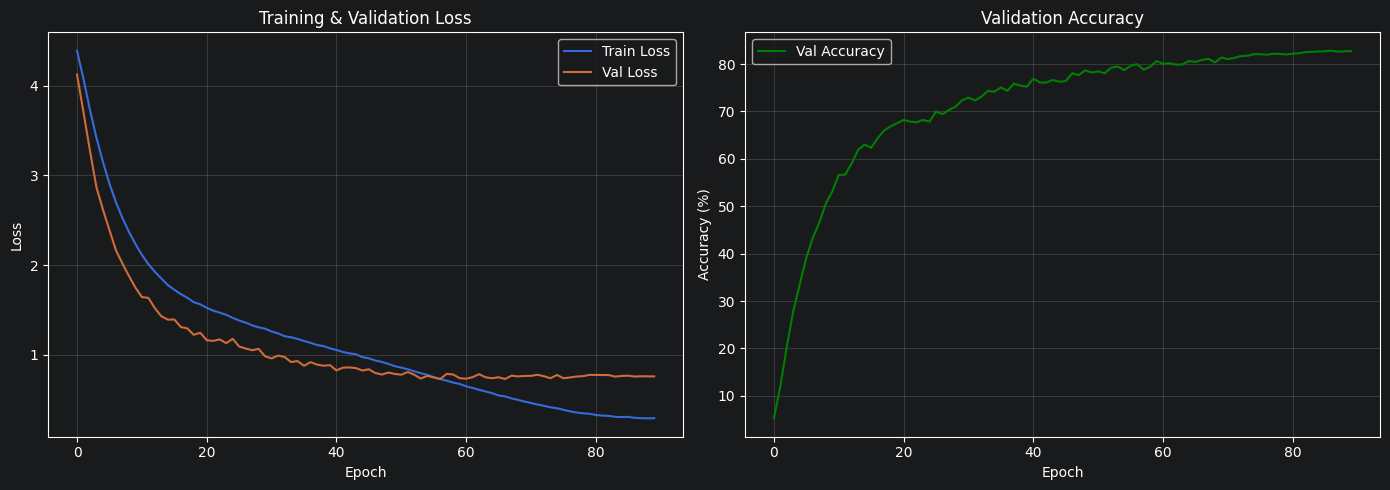

In [9]:
plot_training_curves(train_losses, val_losses, val_accuracies)


In [10]:
raise NameError

NameError: 